In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("results")
STRATEGIES = ["random", "outlier", "artificial"]
FORMAL_EPSILON = 10.0

In [19]:
# Load results
dfs = []
for s in STRATEGIES:
    path = RESULTS_DIR / f"{s}_strategy" / f"effeps_{s}.csv"
    if path.exists():
        df = pd.read_csv(path)
        df["strategy"] = s
        dfs.append(df)
        print(f"loaded {s} ({len(df)} attacks)")
    else:
        print(f"{s} not yet available")

all_results = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
all_results

loaded random (5 attacks)
loaded outlier (5 attacks)
loaded artificial (5 attacks)


,attack,num_train,num_test,wall_time_s,peak_memory_mb,auc,mia_advantage,privacy_gain,tp,fp,eff_epsilon_pointwise,eff_epsilon_pointwise_is_inf,eps_low_90,eps_high_90,eps_low_95,eps_high_95,eps_low_99,eps_high_99,strategy,formal_epsilon
0,Groundhog,50,100,2185.27,360.81,1.0,1.0,0.0,1.0,0.0,NaN,True,2.390153,inf,2.209964,inf,1.878477,inf,random,10.0
1,ShadowModelling(RandomQueries),50,100,67.28,1.03,1.0,1.0,0.0,1.0,0.0,NaN,True,2.390153,inf,2.209964,inf,1.878477,inf,random,10.0
2,"LocalNeighbourhood(L_2, 0.250411558405805, acc...",50,100,0.44,1.09,0.5,0.0,1.0,0.0,0.0,0.0,False,0.000000,0.085788,0.000000,0.101908,0.000000,0.139336,random,10.0
3,ProbabilityEstimation(KernelDensity()),50,100,0.53,0.94,0.0,0.0,1.0,0.0,0.0,0.0,False,0.000000,0.085788,0.000000,0.101908,0.000000,0.139336,random,10.0
4,"ClosestDistance(L_2, accuracy)",50,100,0.41,1.08,0.0,0.0,1.0,0.0,0.0,0.0,False,0.000000,0.085788,0.000000,0.101908,0.000000,0.139336,random,10.0
5,Groundhog,50,100,2140.89,360.98,1.0,1.0,0.0,1.0,0.0,NaN,True,2.390153,inf,2.209964,inf,1.878477,inf,outlier,10.0
6,ShadowModelling(RandomQueries),50,100,67.71,1.05,1.0,1.0,0.0,1.0,0.0,NaN,True,2.390153,inf,2.209964,inf,1.878477,inf,outlier,10.0
7,"LocalNeighbourhood(L_2, 2.8497639804521993, ac...",50,100,0.49,1.09,1.0,1.0,0.0,1.0,0.0,NaN,True,2.390153,inf,2.209964,inf,1.878477,inf,outlier,10.0
8,ProbabilityEstimation(KernelDensity()),50,100,0.55,0.94,0.0,0.0,1.0,0.0,0.0,0.0,False,0.000000,0.085788,0.000000,0.101908,0.000000,0.139336,outlier,10.0
9,"ClosestDistance(L_2, accuracy)",50,100,0.49,1.08,1.0,1.0,0.0,1.0,0.0,NaN,True,2.390153,inf,2.209964,inf,1.878477,inf,outlier,10.0


# Tables/Statistics

In [20]:
# Combined table: tp, fp, auc, εeff 95% CI per attack × strategy
all_results["attack_family"] = all_results["attack"].apply(
    lambda x: "LocalNeighbourhood" if "LocalNeighbourhood" in x else x.split("(")[0]
)

all_results["eps_ci_95"] = all_results.apply(
    lambda r: f"[{r.eps_low_95:.3f}, {'∞' if np.isinf(r.eps_high_95) or r.eps_high_95 > 1e6 else f'{r.eps_high_95:.3f}'}]",
    axis=1,
)

combined = all_results.pivot_table(
    index="attack_family",
    columns="strategy",
    values=["tp", "fp", "auc", "eps_ci_95"],
    aggfunc="first",
)

# Reorder columns: group by strategy, then metrics within each
attack_order = ["Groundhog", "ShadowModelling", "ClosestDistance", "LocalNeighbourhood", "ProbabilityEstimation"]
strategy_order = ["random", "outlier", "artificial"]

combined = combined.reindex(attack_order)
combined = combined.reindex(["tp", "fp", "auc", "eps_ci_95"], axis=1, level=0)
combined = combined.reindex(strategy_order, axis=1, level="strategy")
combined = combined.reindex(attack_order)
combined

tp                        fp                     \
strategy              random outlier artificial random outlier artificial   
attack_family                                                               
Groundhog                1.0     1.0        1.0    0.0     0.0        0.0   
ShadowModelling          1.0     1.0        1.0    0.0     0.0        0.0   
ClosestDistance          0.0     1.0        1.0    0.0     0.0        0.0   
LocalNeighbourhood       0.0     1.0        1.0    0.0     0.0        0.0   
ProbabilityEstimation    0.0     0.0        1.0    0.0     0.0        0.0   

                         auc                          eps_ci_95  \
strategy              random outlier artificial          random   
attack_family                                                     
Groundhog                1.0     1.0        1.0      [2.210, ∞]   
ShadowModelling          1.0     1.0        1.0      [2.210, ∞]   
ClosestDistance          0.0     1.0        1.0  [0.000, 0.102]   
LocalNeighbourhood       0.5     1.0        1.0  [0.000, 0.102]   
ProbabilityEstimation    0.0     0.0        1.0  [0.000, 0.102]   

                                                   
strategy                      outlier  artificial  
attack_family                                      
Groundhog                  [2.210, ∞]  [2.210, ∞]  
ShadowModelling            [2.210, ∞]  [2.210, ∞]  
ClosestDistance            [2.210, ∞]  [2.210, ∞]  
LocalNeighbourhood         [2.210, ∞]  [2.210, ∞]  
ProbabilityEstimation  [0.000, 0.102]  [2.210, ∞]

In [22]:
# Max εeff per strategy (headline number)
headline = all_results.groupby("strategy").agg(
    max_auc=("auc", "max"),
    max_eps_low_95=("eps_low_95", "max"),
    best_attack=("eps_low_95", lambda x: all_results.loc[x.idxmax(), "attack"]),
).reindex(STRATEGIES)
headline["formal_epsilon"] = FORMAL_EPSILON
headline["gap"] = FORMAL_EPSILON - headline["max_eps_low_95"]
headline

,max_auc,max_eps_low_95,best_attack,formal_epsilon,gap
strategy,,,,,
random,1.0,2.209964,Groundhog,10.0,7.790036
outlier,1.0,2.209964,Groundhog,10.0,7.790036
artificial,1.0,2.209964,Groundhog,10.0,7.790036


# Figures

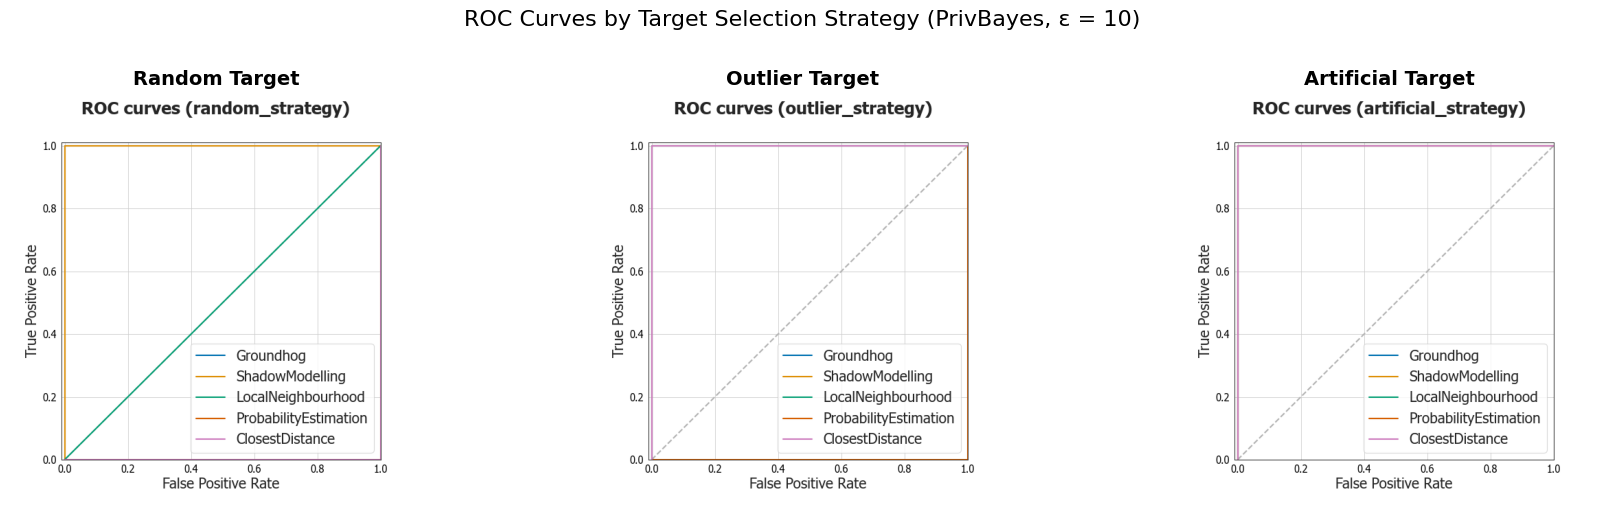

In [23]:
# Side-by-side ROC curves from each strategy's saved PNG
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, s in enumerate(STRATEGIES):
    img_path = RESULTS_DIR / f"{s}_strategy" / f"ROC_curve_{s}_strategy.png"
    if img_path.exists():
        img = plt.imread(str(img_path))
        axes[i].imshow(img)
        axes[i].set_title(f"{s.capitalize()} Target", fontsize=14, fontweight="bold")
    else:
        axes[i].text(0.5, 0.5, f"{s}\nnot available", ha="center", va="center")
    axes[i].axis("off")

plt.suptitle("ROC Curves by Target Selection Strategy (PrivBayes, ε = 10)", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "roc_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()